# Scenario Comparison: A+ / B+ / C+ vs Baseline

In [115]:
import warnings
import logging
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pypsa
import yaml

pd.set_option('display.max_rows', 100)

BASE = '.'

# ── Scenario paths ───────────────────────────────────────────────────────────
# TODO: update sub-scenario names to *_newcosts once all no-TES + new-costs
#       runs (A+, B+, C+) have finished. Expected naming convention:
#       alpine_all_nosimp_no_tes  →  alpine_all_nosimp_no_tes_newcosts
# ─────────────────────────────────────────────────────────────────────────────
SCENARIOS = {
    'Baseline(no alpine)': f'{BASE}/Baseline_imp5_simp0_g5/baseline_all_nosimp_no_tes/networks/base_s_adm___2050.nc',
    'B+(cold 1985/86)':    f'{BASE}/8586_B+_imp5_simp0_g5/alpine_final/networks/base_s_adm___2050.nc',
    'C+(moderate 2017/18)':f'{BASE}/1718_C+_imp5_simp0_g5/alpine_final/networks/base_s_adm___2050.nc',
    'A+(warm 2006/07)':    f'{BASE}/0607_A+_imp5_simp0_g5/alpine_final/networks/base_s_adm___2050.nc',
}

COLORS = {
    'Baseline(no alpine)':  '#888888',
    'B+(cold 1985/86)':     '#2166ac',
    'C+(moderate 2017/18)': '#4dac26',
    'A+(warm 2006/07)':     '#e6700a',
}

with open('../config/plotting.default.yaml') as f:
    TECH_COLORS = yaml.safe_load(f)['plotting']['tech_colors']

networks = {name: pypsa.Network(path) for name, path in SCENARIOS.items()}
print('Loaded:', list(networks.keys()))

Loaded: ['Baseline(no alpine)', 'B+(cold 1985/86)', 'C+(moderate 2017/18)', 'A+(warm 2006/07)']


## 1. Alpine PV Capacity by Scenario

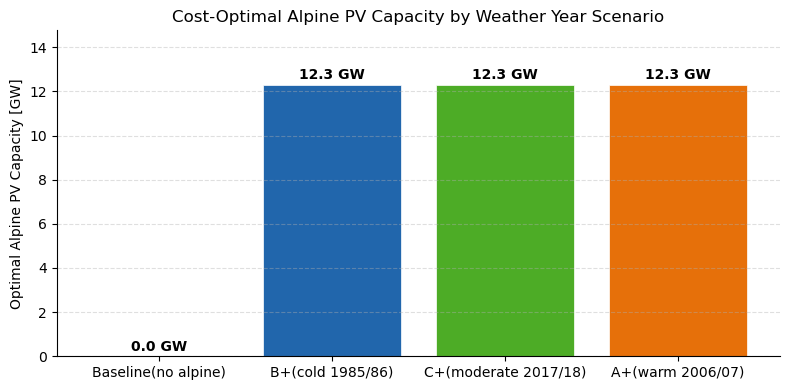

Baseline(no alpine)      0.0
B+(cold 1985/86)        12.3
C+(moderate 2017/18)    12.3
A+(warm 2006/07)        12.3
Name: Alpine PV [GW], dtype: float64


In [116]:
fig, ax = plt.subplots(figsize=(8, 4))

alpine_caps = {}
for name, n in networks.items():
    # CH-only: border pixels sit on the IT bus (feed the Italian node) and are excluded.
    g = n.generators
    alpine = g[(g.carrier == 'alpine-solar') & g.bus.astype(str).str.startswith('CH')]
    alpine_caps[name] = alpine.p_nom_opt.sum() / 1e3  # GW

labels = list(alpine_caps.keys())
values = list(alpine_caps.values())
colors = [COLORS[l] for l in labels]

bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f} GW', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Optimal Alpine PV Capacity [GW]')
ax.set_title('Cost-Optimal Alpine PV Capacity by Weather Year Scenario')
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/alpine_pv_capacity_comparison.pdf', bbox_inches='tight')
plt.show()
print(pd.Series(alpine_caps, name='Alpine PV [GW]').round(2))

## 2. Alpine PV Capacity by Canton

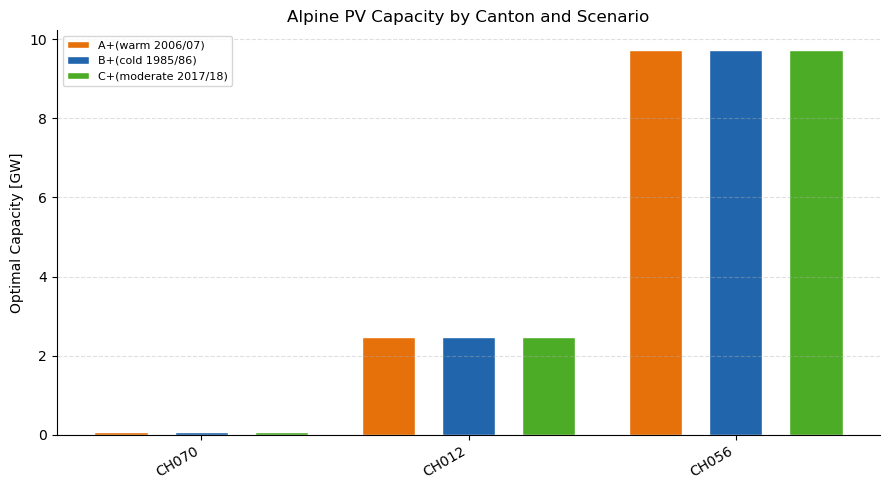

In [117]:
canton_dfs = []
for name, n in networks.items():
    # CH-only: exclude border pixels on the IT bus (they feed the Italian node).
    g = n.generators
    alpine = g[(g.carrier == 'alpine-solar') & g.bus.astype(str).str.startswith('CH')].copy()
    alpine['scenario'] = name
    alpine['p_nom_opt_GW'] = alpine.p_nom_opt / 1e3
    canton_dfs.append(alpine[['bus', 'p_nom_opt_GW', 'scenario']])

df_canton = pd.concat(canton_dfs)
df_canton = df_canton[df_canton.p_nom_opt_GW > 0.001]

pivot = df_canton.pivot_table(index='bus', columns='scenario', values='p_nom_opt_GW', fill_value=0)
# Keep sites with max capacity >= 0.05 GW: includes CH070 (80 MW),
# drops the negligible CH021+1 (7 MW) and CH062+1 (2 MW).
pivot = pivot[pivot.max(axis=1) >= 0.05]
pivot = pivot.sort_values('A+(warm 2006/07)', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pivot))
width = 0.2
offsets = np.linspace(-1.5*width, 1.5*width, len(pivot.columns))

for i, col in enumerate(pivot.columns):
    ax.bar(x + offsets[i], pivot[col], width, label=col.replace('\n', ' '),
           color=COLORS[col], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=30, ha='right')
ax.set_ylabel('Optimal Capacity [GW]')
ax.set_title('Alpine PV Capacity by Canton and Scenario')
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/alpine_pv_by_canton.pdf', bbox_inches='tight')
plt.show()

## 3. Total System Costs

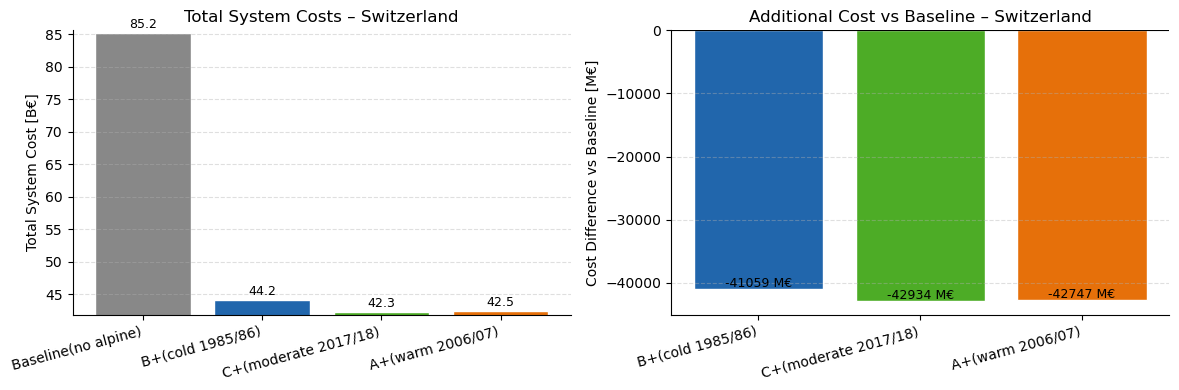

                      CAPEX  Total
Baseline(no alpine)   85.20  85.21
B+(cold 1985/86)      44.15  44.15
C+(moderate 2017/18)  42.27  42.28
A+(warm 2006/07)      42.46  42.46


In [118]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

def ch_only(n, c, **kwargs):
    df = n.df(c)
    bus_col = 'bus' if 'bus' in df.columns else 'bus0'
    return df['carrier'].where(df[bus_col].str.startswith('CH'))

cost_data = {}
for name, n in networks.items():
    stats = n.statistics
    cost_data[name] = {
        'CAPEX': stats.capex(nice_names=False, groupby=ch_only).sum() / 1e9,
        'OPEX':  stats.opex(nice_names=False,  groupby=ch_only).sum() / 1e9,
    }

df_costs = pd.DataFrame(cost_data).T
df_costs['Total'] = df_costs['CAPEX'] + df_costs['OPEX']

# Left: CH total system costs
ax = axes[0]
bars = ax.bar(df_costs.index, df_costs['Total'],
              color=[COLORS[l] for l in df_costs.index], edgecolor='white')
for bar, val in zip(bars, df_costs['Total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Total System Cost [B€]')
ax.set_title('Total System Costs – Switzerland')
ymin = df_costs['Total'].min() * 0.99
ymax = df_costs['Total'].max() * 1.005
ax.set_ylim(ymin, ymax)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([l.replace('\n', ' ') for l in df_costs.index], rotation=15, ha='right')

# Right: Cost difference vs baseline in M€
ax2 = axes[1]
baseline_cost = df_costs.loc['Baseline(no alpine)', 'Total']
diff = (df_costs['Total'] - baseline_cost) * 1e3  # M€
diff_no_base = diff.drop('Baseline(no alpine)')
bar_colors = [COLORS[l] for l in diff_no_base.index]
bars2 = ax2.bar(diff_no_base.index, diff_no_base, color=bar_colors, edgecolor='white')
for bar, val in zip(bars2, diff_no_base):
    ypos = bar.get_height() + (20 if val >= 0 else -80)
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:+.0f} M€', ha='center', va='bottom', fontsize=9)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Cost Difference vs Baseline [M€]')
ax2.set_title('Additional Cost vs Baseline – Switzerland')
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticklabels([l.replace('\n', ' ') for l in diff_no_base.index], rotation=15, ha='right')

plt.tight_layout()
plt.savefig('figures/system_costs_comparison.pdf', bbox_inches='tight')
plt.show()
print(df_costs[['CAPEX','Total']].round(2))


## 4. Technology Mix – Power Capacities CH

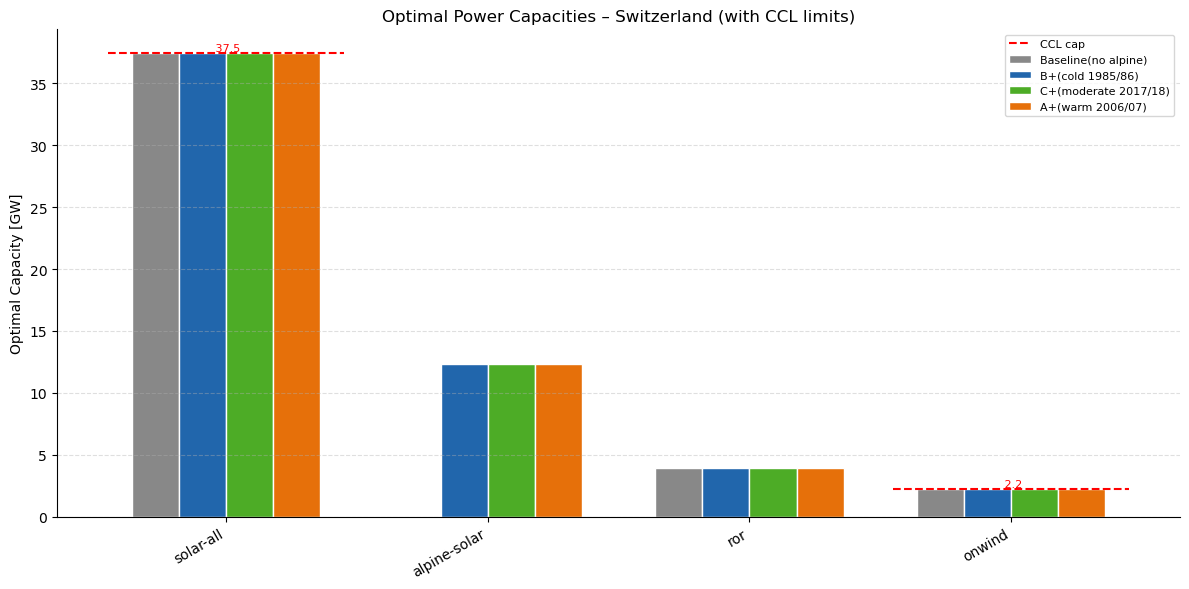

CH capacities [GW] (solar-all = solar + solar-hsat + solar rooftop):
              Baseline(no alpine)  B+(cold 1985/86)  C+(moderate 2017/18)  \
carrier                                                                     
solar-all                   37.50             37.50                 37.50   
alpine-solar                 0.00             12.30                 12.30   
ror                          3.89              3.89                  3.89   
onwind                       2.20              2.20                  2.20   

              A+(warm 2006/07)  
carrier                         
solar-all                37.50  
alpine-solar             12.30  
ror                       3.89  
onwind                    2.20  

CCL caps [GW]: {'solar-all': 37.5, 'onwind': 2.2}

Flatland-solar breakdown [GW]:
               Baseline(no alpine)  B+(cold 1985/86)  C+(moderate 2017/18)  \
carrier                                                                      
solar                          

In [119]:
# CH power capacities by carrier, with EP2050+ CCL caps drawn as red dashed segments.
# The CCL cap is on the AGGREGATE 'solar-all' (solar + solar-hsat + solar rooftop) = 37.5 GW,
# so the three flatland-solar carriers are merged into one 'solar-all' group here.
# onwind cap = 2.2 GW. alpine-solar is a SEPARATE carrier -> NOT part of solar-all, uncapped.
SOLAR_ALL = ['solar', 'solar-hsat', 'solar rooftop']
CH_CCL_CAPS = {'solar-all': 37.5, 'onwind': 2.2}  # GW, data/agg_p_nom_minmax.csv (EP2050+ ZERO Basis 2050)

def get_ch_optimal_capacity(n):
    gens = n.generators[n.generators.bus.str.startswith('CH')]
    cap = gens.groupby('carrier')['p_nom_opt'].sum() / 1e3  # GW
    # merge flatland-solar carriers into the CCL-aggregated 'solar-all'
    present = [c for c in SOLAR_ALL if c in cap.index]
    solar_all = cap.reindex(SOLAR_ALL).fillna(0).sum()
    cap = cap.drop(index=present, errors='ignore')
    cap['solar-all'] = solar_all
    return cap

cap_data = {name: get_ch_optimal_capacity(n) for name, n in networks.items()}
df_cap = pd.DataFrame(cap_data).fillna(0)

# Keep only carriers with meaningful capacity
df_cap = df_cap[df_cap.max(axis=1) > 0.1]
df_cap = df_cap.sort_values('A+(warm 2006/07)', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_cap))
n_scen = len(df_cap.columns)
width = 0.18
offsets = np.linspace(-(n_scen-1)/2*width, (n_scen-1)/2*width, n_scen)

for i, col in enumerate(df_cap.columns):
    ax.bar(x + offsets[i], df_cap[col], width,
           label=col.replace('\n', ' '), color=COLORS[col], edgecolor='white')

# CCL upper limits as red dashed segments over the matching carrier group
cap_drawn = False
for j, carrier in enumerate(df_cap.index):
    cap = CH_CCL_CAPS.get(carrier)
    if cap is not None:
        ax.hlines(cap, x[j] - 0.45, x[j] + 0.45, color='red', linestyle='--',
                  linewidth=1.5, zorder=5, label='CCL cap' if not cap_drawn else None)
        ax.text(x[j], cap, f' {cap:g}', ha='center', va='bottom', fontsize=8, color='red')
        cap_drawn = True

ax.set_xticks(x)
ax.set_xticklabels(df_cap.index, rotation=30, ha='right')
ax.set_ylabel('Optimal Capacity [GW]')
ax.set_title('Optimal Power Capacities – Switzerland (with CCL limits)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/technology_mix_comparison.pdf', bbox_inches='tight')
plt.show()

print('CH capacities [GW] (solar-all = solar + solar-hsat + solar rooftop):')
print(df_cap.round(2))
print('\nCCL caps [GW]:', CH_CCL_CAPS)

# detail: flatland-solar split per scenario (info only; merged in the chart above)
solar_detail = pd.DataFrame({
    name: n.generators[n.generators.bus.str.startswith('CH')]
            .groupby('carrier')['p_nom_opt'].sum().reindex(SOLAR_ALL).fillna(0) / 1e3
    for name, n in networks.items()
})
print('\nFlatland-solar breakdown [GW]:')
print(solar_detail.round(2))


## 5. Alpine PV Capacity Factor Profiles

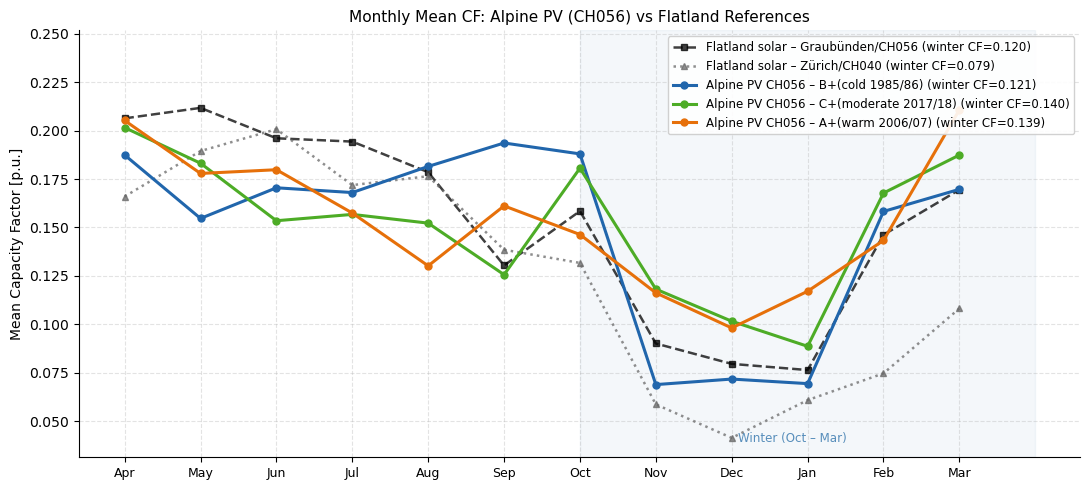

Winter CF (Oct-Mar):
  Alpine PV B+(cold 1985/86)         : 0.121
  Alpine PV C+(moderate 2017/18)     : 0.140
  Alpine PV A+(warm 2006/07)         : 0.139
  Flatland Graubünden (CH056)     : 0.120
  Flatland Zürich     (CH040)     : 0.079


In [120]:
fig, ax = plt.subplots(figsize=(11, 5))

months_order = [4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3]
month_labels = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']

n_ref = networks['C+(moderate 2017/18)']
all_values = []

# ── Flatland references (drawn first so they sit behind alpine lines) ──────
cf_ch056 = n_ref.generators_t.p_max_pu.get('CH056 0 solar')
if cf_ch056 is not None:
    m56 = [cf_ch056[cf_ch056.index.month == m].mean() for m in months_order]
    all_values.extend(m56)
    ax.plot(range(12), m56, color='black', linewidth=1.8, linestyle='--',
            marker='s', markersize=4, alpha=0.75,
            label=f'Flatland solar – Graubünden/CH056 (winter CF={cf_ch056[cf_ch056.index.month.isin([10,11,12,1,2,3])].mean():.3f})')

cf_ch040 = n_ref.generators_t.p_max_pu.get('CH040 0 solar')
if cf_ch040 is not None:
    m40 = [cf_ch040[cf_ch040.index.month == m].mean() for m in months_order]
    all_values.extend(m40)
    ax.plot(range(12), m40, color='dimgray', linewidth=1.8, linestyle=':',
            marker='^', markersize=4, alpha=0.75,
            label=f'Flatland solar – Zürich/CH040 (winter CF={cf_ch040[cf_ch040.index.month.isin([10,11,12,1,2,3])].mean():.3f})')

# ── Alpine PV scenario lines ───────────────────────────────────────────────
alpine_scenarios = ['B+(cold 1985/86)', 'C+(moderate 2017/18)', 'A+(warm 2006/07)']
for name in alpine_scenarios:
    n = networks[name]
    gen_name = 'CH056 0 alpine-solar'
    if gen_name not in n.generators_t.p_max_pu.columns:
        continue
    cf = n.generators_t.p_max_pu[gen_name]
    monthly = [cf[cf.index.month == m].mean() for m in months_order]
    all_values.extend(monthly)
    winter_cf = cf[cf.index.month.isin([10,11,12,1,2,3])].mean()
    ax.plot(range(12), monthly, marker='o', markersize=5, linewidth=2.2,
            color=COLORS[name],
            label=f'Alpine PV CH056 – {name.replace(chr(10), " ")} (winter CF={winter_cf:.3f})')

# ── Dynamic y-limits ───────────────────────────────────────────────────────
pad = 0.01
ylo = min(all_values) - pad
yhi = max(all_values) + pad * 4
ax.set_ylim(ylo, yhi)

# ── Winter shading & annotation ───────────────────────────────────────────
ax.axvspan(6, 11.99, alpha=0.06, color='steelblue', zorder=0)
ax.text(8.8, ylo + 0.008, 'Winter (Oct – Mar)', fontsize=8.5, color='steelblue',
        alpha=0.9, ha='center')

# ── Formatting ────────────────────────────────────────────────────────────
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels, fontsize=9)
ax.set_ylabel('Mean Capacity Factor [p.u.]', fontsize=10)
ax.set_title('Monthly Mean CF: Alpine PV (CH056) vs Flatland References', fontsize=11)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
ax.grid(linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/alpine_pv_cf_profiles.pdf', bbox_inches='tight')
plt.show()

# ── Print winter CF table ─────────────────────────────────────────────────
print('Winter CF (Oct-Mar):')
for name in alpine_scenarios:
    cf = networks[name].generators_t.p_max_pu.get('CH056 0 alpine-solar')
    if cf is not None:
        print(f'  Alpine PV {name.replace(chr(10)," "):25s}: {cf[cf.index.month.isin([10,11,12,1,2,3])].mean():.3f}')
if cf_ch056 is not None:
    print(f'  Flatland Graubünden (CH056)     : {cf_ch056[cf_ch056.index.month.isin([10,11,12,1,2,3])].mean():.3f}')
if cf_ch040 is not None:
    print(f'  Flatland Zürich     (CH040)     : {cf_ch040[cf_ch040.index.month.isin([10,11,12,1,2,3])].mean():.3f}')

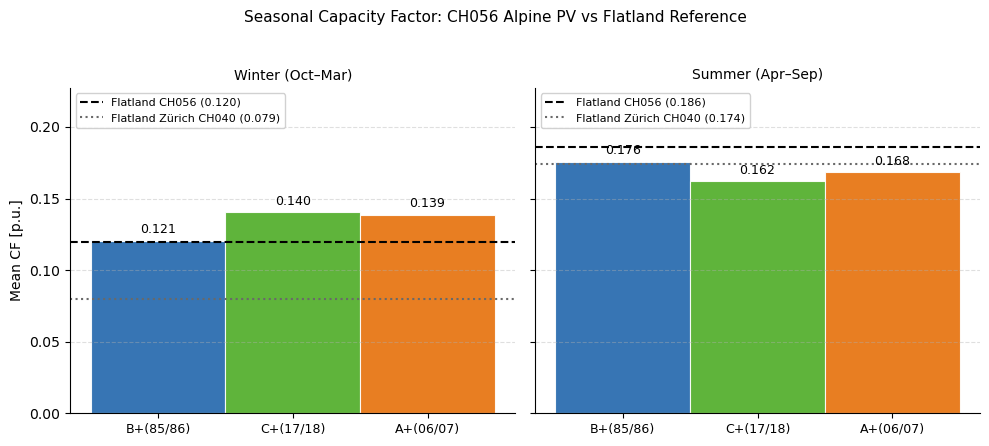

In [128]:
# Seasonal capacity factor: CH056 alpine PV vs flatland references — winter | summer panels (shared y).
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

alpine_scenarios = ["B+(cold 1985/86)", "C+(moderate 2017/18)", "A+(warm 2006/07)"]
short = {"B+(cold 1985/86)": "B+(85/86)", "C+(moderate 2017/18)": "C+(17/18)", "A+(warm 2006/07)": "A+(06/07)"}
W = [10, 11, 12, 1, 2, 3]
S = [4, 5, 6, 7, 8, 9]

winter_cfs, summer_cfs, xlabels, colors_scen = [], [], [], []
for name in alpine_scenarios:
    cf = networks[name].generators_t.p_max_pu.get("CH056 0 alpine-solar")
    if cf is None:
        continue
    winter_cfs.append(cf[cf.index.month.isin(W)].mean())
    summer_cfs.append(cf[cf.index.month.isin(S)].mean())
    xlabels.append(short[name])
    colors_scen.append(COLORS[name])

# Flatland references are identical in all runs (fixed base year) -> use any run.
n_ref = networks["C+(moderate 2017/18)"]
def _cf(gen, months):
    s = n_ref.generators_t.p_max_pu.get(gen)
    return s[s.index.month.isin(months)].mean() if s is not None else None
fw56, fs56 = _cf("CH056 0 solar", W), _cf("CH056 0 solar", S)
fw40, fs40 = _cf("CH040 0 solar", W), _cf("CH040 0 solar", S)

x = np.arange(len(xlabels))
for ax, vals, r56, r40, ttl in [
    (axL, winter_cfs, fw56, fw40, "Winter (Oct–Mar)"),
    (axR, summer_cfs, fs56, fs40, "Summer (Apr–Sep)"),
]:
    bars = ax.bar(x, vals, 1.0, color=colors_scen, alpha=0.9, edgecolor="white", linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
    if r56 is not None:
        ax.axhline(r56, color="black", lw=1.5, ls="--", label=f"Flatland CH056 ({r56:.3f})")
    if r40 is not None:
        ax.axhline(r40, color="dimgray", lw=1.5, ls=":", label=f"Flatland Zürich CH040 ({r40:.3f})")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(ttl, fontsize=10)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axL.set_ylabel("Mean CF [p.u.]")
axL.set_ylim(0, max(summer_cfs + [v for v in [fs56, fs40] if v is not None]) * 1.22)
fig.suptitle("Seasonal Capacity Factor: CH056 Alpine PV vs Flatland Reference", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("figures/alpine_pv_cf_winter_summer.pdf", bbox_inches="tight")
plt.show()

## 6. Net Imports Switzerland

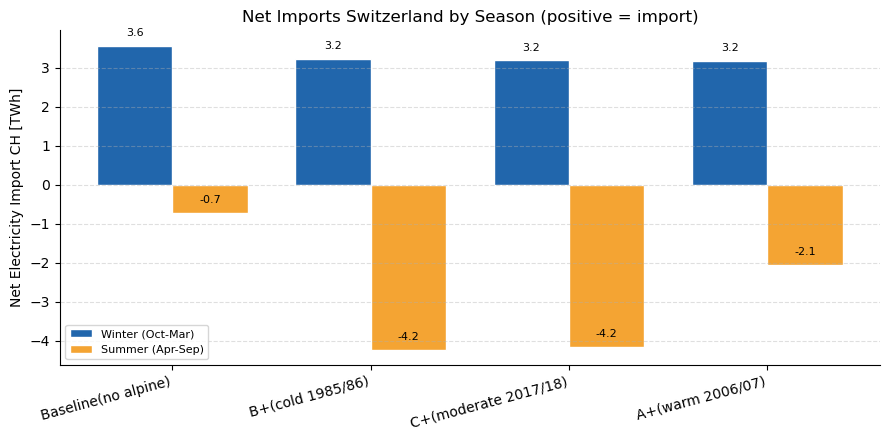

                      Winter (Oct-Mar)  Summer (Apr-Sep)  Annual
Baseline(no alpine)                3.6              -0.7     2.8
B+(cold 1985/86)                   3.2              -4.2    -1.0
C+(moderate 2017/18)               3.2              -4.2    -1.0
A+(warm 2006/07)                   3.2              -2.1     1.1


In [122]:
fig, ax = plt.subplots(figsize=(9, 4.5))
W = [10, 11, 12, 1, 2, 3]  # winter = Oct-Mar

rows = {}
for name, n in networks.items():
    eb = n.statistics.energy_balance(aggregate_time=False, nice_names=False, groupby=['bus', 'carrier'])
    ch = eb[eb.index.get_level_values('bus').str.startswith('CH')]
    ac = ch[ch.index.get_level_values('carrier') == 'AC'].sum(axis=0)  # sum CH buses, per snapshot
    e = ac * n.snapshot_weightings.generators / 1e6  # TWh per snapshot
    win = e[e.index.month.isin(W)].sum()
    summ = e[~e.index.month.isin(W)].sum()
    rows[name] = {'Winter (Oct-Mar)': win, 'Summer (Apr-Sep)': summ, 'Annual': win + summ}

df_imp = pd.DataFrame(rows).T
labels = list(rows.keys())
x = np.arange(len(labels))
w = 0.38

b1 = ax.bar(x - w/2, df_imp['Winter (Oct-Mar)'], w, label='Winter (Oct-Mar)', color='#2166ac', edgecolor='white')
b2 = ax.bar(x + w/2, df_imp['Summer (Apr-Sep)'], w, label='Summer (Apr-Sep)', color='#f4a433', edgecolor='white')
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([l.replace('\n', ' ') for l in labels], rotation=15, ha='right')
ax.set_ylabel('Net Electricity Import CH [TWh]')
ax.set_title('Net Imports Switzerland by Season (positive = import)')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/net_imports_comparison.pdf', bbox_inches='tight')
plt.show()
print(df_imp.round(1))

## 7. Monthly Curtailment Alpine PV

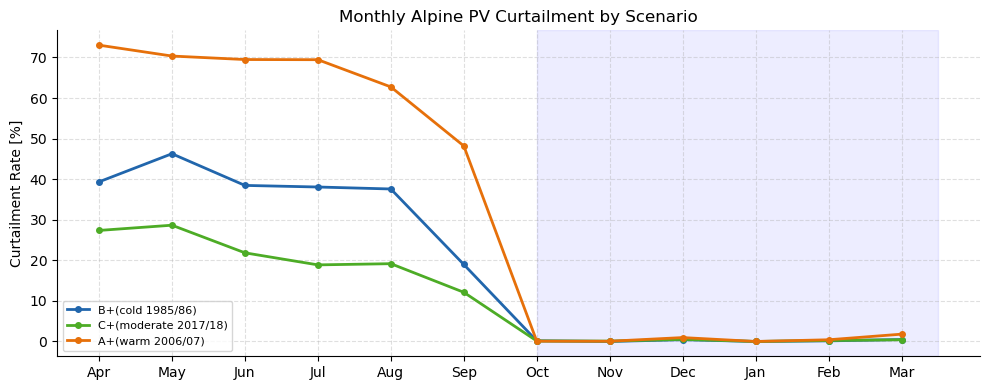

In [123]:
fig, ax = plt.subplots(figsize=(10, 4))

months_order = [4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3]
month_labels = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']

for name, n in networks.items():
    # CH-only: exclude border pixels on the IT bus.
    g = n.generators
    alpine_idx = g[(g.carrier == 'alpine-solar') & g.bus.astype(str).str.startswith('CH')].index
    p_nom_opt = n.generators.loc[alpine_idx, 'p_nom_opt']
    if p_nom_opt.sum() < 1:  # MW; skips Baseline (no alpine)
        continue
    potential = n.generators_t.p_max_pu[alpine_idx].multiply(p_nom_opt, axis=1)
    actual = n.generators_t.p[alpine_idx]
    curtailment = potential - actual

    monthly_pct = []
    for m in months_order:
        mask = potential.index.month == m
        pot_m = potential[mask].values.sum()
        cur_m = curtailment[mask].values.sum()
        monthly_pct.append(cur_m / pot_m * 100 if pot_m > 0 else 0)

    ax.plot(range(12), monthly_pct, marker='o', label=name.replace('\n', ' '),
            color=COLORS[name], linewidth=2, markersize=4)

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Curtailment Rate [%]')
ax.set_title('Monthly Alpine PV Curtailment by Scenario')
ax.legend(fontsize=8)
ax.axvspan(6, 11.5, alpha=0.07, color='blue')
ax.grid(linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/curtailment_comparison.pdf', bbox_inches='tight')
plt.show()

## 8. Alpine vs Flatland Solar LCOE

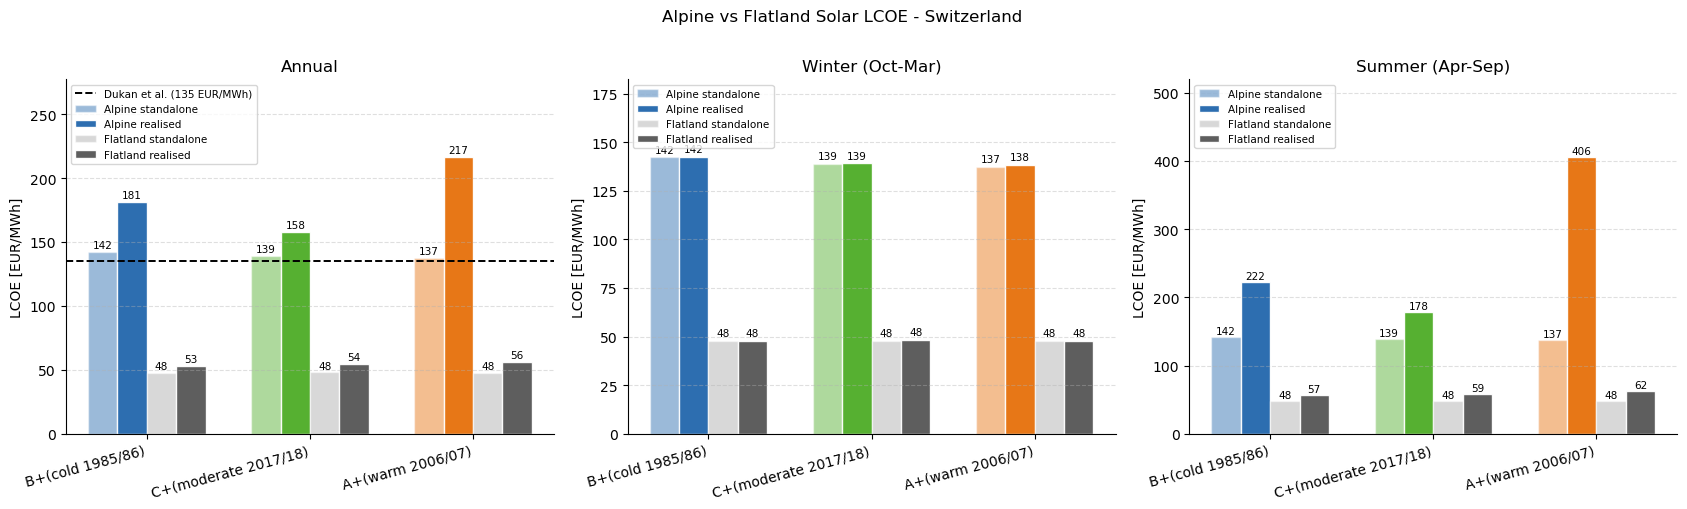

Alpine LCOE [EUR/MWh]:
                      stand_ann  real_ann  stand_win  real_win  stand_sum  \
B+(cold 1985/86)          142.0     181.0      142.0     142.0      142.0   
C+(moderate 2017/18)      139.0     158.0      139.0     139.0      139.0   
A+(warm 2006/07)          137.0     217.0      137.0     138.0      137.0   

                      real_sum  
B+(cold 1985/86)         222.0  
C+(moderate 2017/18)     178.0  
A+(warm 2006/07)         406.0  

Flatland LCOE [EUR/MWh]:
                      stand_ann  real_ann  stand_win  real_win  stand_sum  \
B+(cold 1985/86)           48.0      53.0       48.0      48.0       48.0   
C+(moderate 2017/18)       48.0      54.0       48.0      48.0       48.0   
A+(warm 2006/07)           48.0      56.0       48.0      48.0       48.0   

                      real_sum  
B+(cold 1985/86)          57.0  
C+(moderate 2017/18)      59.0  
A+(warm 2006/07)          62.0  


In [124]:
alpine_scenarios = ['B+(cold 1985/86)', 'C+(moderate 2017/18)', 'A+(warm 2006/07)']
FLATLAND_CARRIERS = ['solar', 'solar-hsat', 'solar rooftop']
DUKAN = 135
W = [10, 11, 12, 1, 2, 3]
S = [4,  5,  6, 7, 8, 9]

def lcoe_full(n, carriers, ch_only=True):
    """Standalone and realised LCOE for annual / winter / summer."""
    g   = n.generators
    w   = n.snapshot_weightings.generators
    sel = g[g.carrier.isin(carriers)]
    if ch_only:
        sel = sel[sel.bus.astype(str).str.startswith('CH')]
    nan6 = {k: np.nan for k in ['stand_ann','real_ann','stand_win','real_win','stand_sum','real_sum']}
    if sel.empty or sel.p_nom_opt.sum() < 1:
        return nan6
    ids       = [i for i in sel.index if i in n.generators_t.p_max_pu.columns]
    cap_costs = (sel.capital_cost * sel.p_nom_opt).sum()
    avail_ts  = (n.generators_t.p_max_pu[ids]
                 .multiply(sel.loc[ids, 'p_nom_opt'], axis=1)
                 .multiply(w, axis=0))
    disp_ts   = n.generators_t.p[sel.index].multiply(w, axis=0)
    avail_ann = avail_ts.values.sum()
    disp_ann  = disp_ts.values.sum()
    out = {
        'stand_ann': cap_costs / avail_ann if avail_ann > 0 else np.nan,
        'real_ann':  cap_costs / disp_ann  if disp_ann  > 0 else np.nan,
    }
    for suffix, months in [('win', W), ('sum', S)]:
        mask    = avail_ts.index.month.isin(months)
        avail_s = avail_ts[mask].values.sum()
        disp_s  = disp_ts[mask].values.sum()
        capex_s = cap_costs * (avail_s / avail_ann)
        out[f'stand_{suffix}'] = capex_s / avail_s if avail_s > 0 else np.nan
        out[f'real_{suffix}']  = capex_s / disp_s  if disp_s  > 0 else np.nan
    return out

alp_lcoe  = {name: lcoe_full(networks[name], ['alpine-solar']) for name in alpine_scenarios}
flat_lcoe = {name: lcoe_full(networks[name], FLATLAND_CARRIERS)  for name in alpine_scenarios}

labels = [s.replace('\n', ' ') for s in alpine_scenarios]
colors = [COLORS[s] for s in alpine_scenarios]
x      = np.arange(len(labels))
bw     = 0.18
offsets = [-0.27, -0.09, 0.09, 0.27]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

def _panel(ax, key, title, dukan_line=False):
    alp_s  = [alp_lcoe[s][f'stand_{key}']  for s in alpine_scenarios]
    alp_r  = [alp_lcoe[s][f'real_{key}']   for s in alpine_scenarios]
    flat_s = [flat_lcoe[s][f'stand_{key}'] for s in alpine_scenarios]
    flat_r = [flat_lcoe[s][f'real_{key}']  for s in alpine_scenarios]
    groups = [
        (alp_s,  colors, 0.45, 'Alpine standalone'),
        (alp_r,  colors, 0.95, 'Alpine realised'),
        (flat_s, ['#aaaaaa']*3, 0.45, 'Flatland standalone'),
        (flat_r, ['#555555']*3, 0.95, 'Flatland realised'),
    ]
    for (vals, cols, alpha, lbl), off in zip(groups, offsets):
        bars = ax.bar(x + off, vals, bw, color=cols, edgecolor='white',
                      alpha=alpha, label=lbl)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                        f'{val:.0f}', ha='center', va='bottom', fontsize=7.5)
    if dukan_line:
        ax.axhline(DUKAN, color='black', ls='--', lw=1.4,
                   label=f'Dukan et al. ({DUKAN} EUR/MWh)')
    all_v = [v for lst in [alp_s,alp_r,flat_s,flat_r] for v in lst if not np.isnan(v)]
    ax.set_ylim(0, max(all_v) * 1.28)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_ylabel('LCOE [EUR/MWh]'); ax.set_title(title)
    ax.legend(fontsize=7.5, loc='upper left'); ax.grid(axis='y', ls='--', alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

_panel(ax1, 'ann', 'Annual',           dukan_line=True)
_panel(ax2, 'win', 'Winter (Oct-Mar)')
_panel(ax3, 'sum', 'Summer (Apr-Sep)')

plt.suptitle('Alpine vs Flatland Solar LCOE - Switzerland', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/alpine_pv_lcoe_seasonal.pdf', bbox_inches='tight')
plt.show()

print('Alpine LCOE [EUR/MWh]:')
print(pd.DataFrame(alp_lcoe).T.set_axis(labels).round(0))
print('\nFlatland LCOE [EUR/MWh]:')
print(pd.DataFrame(flat_lcoe).T.set_axis(labels).round(0))


## 9. Summary Table

In [125]:
def ch_only_summ(n, c, **kwargs):
    df = n.df(c)
    bus_col = 'bus' if 'bus' in df.columns else 'bus0'
    return df['carrier'].where(df[bus_col].str.startswith('CH'))

rows = []
for name, n in networks.items():
    stats = n.statistics
    w = n.snapshot_weightings.generators
    g = n.generators
    # CH-only: border pixels on the IT bus are excluded (they feed the Italian node).
    alpine = g[(g.carrier == 'alpine-solar') & g.bus.astype(str).str.startswith('CH')]
    alpine_cap = alpine.p_nom_opt.sum() / 1e3

    # Energy (weighted by snapshot duration!) and LCOE
    gen_energy = n.generators_t.p[alpine.index].multiply(w, axis=0).values.sum()  # MWh
    cap_costs = (alpine.capital_cost * alpine.p_nom_opt).sum()
    lcoe = cap_costs / gen_energy if gen_energy > 0 else float('nan')

    # Curtailment alpine (ratio -> weighting cancels, but apply for clarity)
    potential = n.generators_t.p_max_pu[alpine.index].multiply(alpine.p_nom_opt, axis=1).multiply(w, axis=0).values.sum()
    curtailment = (1 - gen_energy / potential) * 100 if potential > 0 else float('nan')

    # CH-only system cost
    ch_cost = (stats.capex(nice_names=False, groupby=ch_only_summ).sum() +
               stats.opex(nice_names=False,  groupby=ch_only_summ).sum()) / 1e9

    # Net imports CH (energy_balance already weighted)
    eb = stats.energy_balance(drop_zero=False, nice_names=False, groupby=['bus', 'carrier'])
    ch_mask = eb.index.get_level_values('bus').str.startswith('CH')
    eb_ch = eb[ch_mask].groupby('carrier').sum()
    net_import = eb_ch.loc['AC'] / 1e6 if 'AC' in eb_ch.index else 0

    rows.append({
        'Scenario': name.replace('\n', ' '),
        'Alpine PV [GW]': round(alpine_cap, 2),
        'Alpine gen [TWh]': round(gen_energy / 1e6, 2),
        'Curtailment [%]': round(curtailment, 1),
        'LCOE alpine [€/MWh]': round(lcoe, 0),
        'CH System Cost [B€]': round(ch_cost, 1),
        'Net Import CH [TWh]': round(net_import, 1),
    })

summary = pd.DataFrame(rows).set_index('Scenario')
display(summary)

,Alpine PV [GW],Alpine gen [TWh],Curtailment [%],LCOE alpine [€/MWh],CH System Cost [B€],Net Import CH [TWh]
Scenario,,,,,,
Baseline(no alpine),0.0,0.00,NaN,NaN,85.2,2.8
B+(cold 1985/86),12.3,12.54,21.5,181.0,44.2,-1.0
C+(moderate 2017/18),12.3,14.39,12.1,158.0,42.3,-1.0
A+(warm 2006/07),12.3,10.49,36.6,217.0,42.5,1.1


## 10. Onshore Wind, Offshore Wind & Solar in Neighbouring Countries

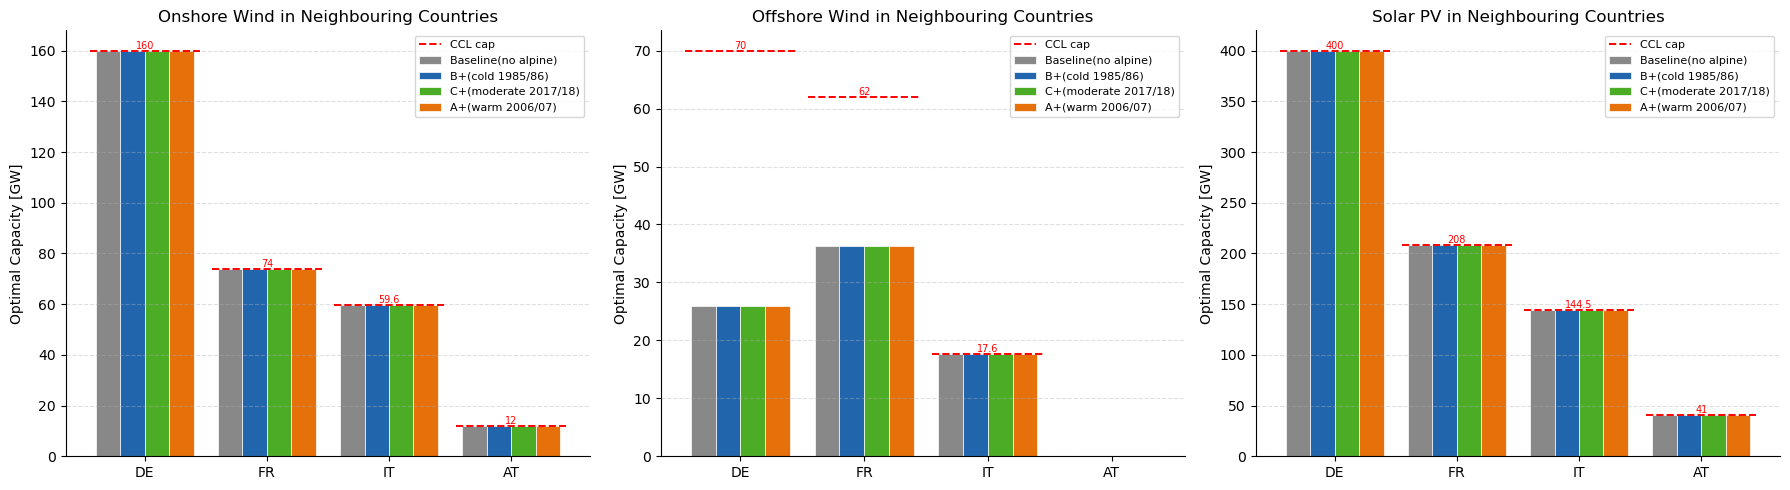

Onshore wind capacity [GW]:
    Baseline(no alpine)  B+(cold 1985/86)  C+(moderate 2017/18)  \
DE                160.0             160.0                 160.0   
FR                 74.0              74.0                  74.0   
IT                 59.6              59.6                  59.6   
AT                 12.0              12.0                  12.0   

    A+(warm 2006/07)  
DE             160.0  
FR              74.0  
IT              59.6  
AT              12.0  

Offshore wind capacity [GW]:
    Baseline(no alpine)  B+(cold 1985/86)  C+(moderate 2017/18)  \
DE                 26.0              26.0                  26.0   
FR                 36.2              36.2                  36.2   
IT                 17.6              17.6                  17.6   
AT                  0.0               0.0                   0.0   

    A+(warm 2006/07)  
DE              26.0  
FR              36.2  
IT              17.6  
AT               0.0  

Solar capacity [GW]:
    Baseline(no al

In [126]:
# ── Onshore wind, offshore wind & solar capacity in CH's neighbours (DE, FR, IT, AT) ──
# Red dashed lines = CCL upper limit from data/agg_p_nom_minmax.csv -> shows if a cap binds.
NEIGHBOURS = ['DE', 'FR', 'IT', 'AT']
SOLAR_CARRIERS = ['solar', 'solar-hsat', 'solar rooftop']         # == agg_solar 'solar-all'
OFFWIND_CARRIERS = ['offwind-ac', 'offwind-dc', 'offwind-float']  # == agg_offwind 'offwind-all'

CAPS = {  # GW, 2050 max from agg_p_nom_minmax.csv; missing key = uncapped
    'onwind':  {'DE': 160, 'FR': 74,  'IT': 59.6,  'AT': 12},
    'offwind': {'DE': 70,  'FR': 62,  'IT': 17.6},  # AT landlocked -> no offshore
    'solar':   {'DE': 400, 'FR': 208, 'IT': 144.5, 'AT': 41},
}

def country_capacity(n, country, carriers):
    g = n.generators
    sel = g[g.bus.astype(str).str.startswith(country) & g.carrier.isin(carriers)]
    return sel.p_nom_opt.sum() / 1e3  # GW

def capacity_df(carriers):
    return pd.DataFrame({
        name: {c: country_capacity(n, c, carriers) for c in NEIGHBOURS}
        for name, n in networks.items()
    })

df_onwind  = capacity_df(['onwind'])
df_offwind = capacity_df(OFFWIND_CARRIERS)
df_solar   = capacity_df(SOLAR_CARRIERS)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, df, tech, title in [
    (axes[0], df_onwind,  'onwind',  'Onshore Wind'),
    (axes[1], df_offwind, 'offwind', 'Offshore Wind'),
    (axes[2], df_solar,   'solar',   'Solar PV'),
]:
    x = np.arange(len(df))
    scen = list(df.columns)
    width = 0.8 / len(scen)
    offsets = np.linspace(-(len(scen) - 1) / 2 * width, (len(scen) - 1) / 2 * width, len(scen))
    for i, col in enumerate(scen):
        ax.bar(x + offsets[i], df[col], width, label=col.replace(chr(10), ' '),
               color=COLORS[col], edgecolor='white', linewidth=0.5)
    for j, c in enumerate(df.index):  # CCL cap as red dashed segment per country
        cap = CAPS[tech].get(c)
        if cap is not None:
            ax.hlines(cap, x[j] - 0.45, x[j] + 0.45, color='red', linestyle='--',
                      linewidth=1.4, zorder=5, label='CCL cap' if j == 0 else None)
            ax.text(x[j], cap, f'{cap:g}', ha='center', va='bottom', fontsize=7, color='red')
    ax.set_xticks(x)
    ax.set_xticklabels(df.index)
    ax.set_ylabel('Optimal Capacity [GW]')
    ax.set_title(f'{title} in Neighbouring Countries')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/neighbour_onwind_offwind_solar.pdf', bbox_inches='tight')
plt.show()

print('Onshore wind capacity [GW]:')
print(df_onwind.round(1))
print('\nOffshore wind capacity [GW]:')
print(df_offwind.round(1))
print('\nSolar capacity [GW]:')
print(df_solar.round(1))

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/Elements/Bachelorarbeit/pulse_pv/p_max_pu/cutouts/neighbours/1985_1986/neighbours_1985_1986.nc'

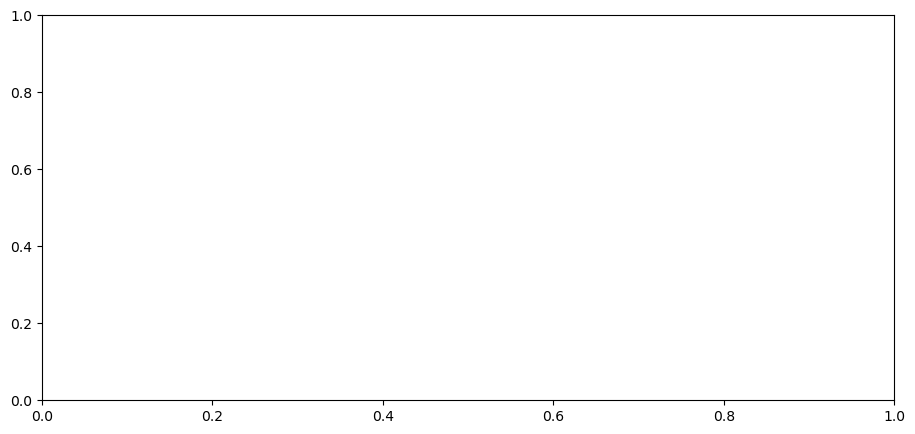

In [127]:
import xarray as xr

fig, ax = plt.subplots(figsize=(11, 5))

months_order = [4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3]
month_labels = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']

CUTOUT_PATHS = {
    'B+\n(cold 1985/86)':     '/Volumes/Elements/Bachelorarbeit/pulse_pv/p_max_pu/cutouts/neighbours/1985_1986/neighbours_1985_1986.nc',
    'C+\n(moderate 2017/18)': '/Users/minosandri/Bachelorarbeit/pypsa-eur_dev/data/cutout/archive/v1.0/neighbours_2017_2018.nc',
    'A+\n(warm 2006/07)':     '/Volumes/Elements/Bachelorarbeit/pulse_pv/p_max_pu/cutouts/neighbours/2006_2007/neighbours_2006_2007.nc',
}

LEGEND_LABELS = {
    'B+\n(cold 1985/86)':     'Grisons Scenario B+ (1985/86)',
    'C+\n(moderate 2017/18)': 'Grisons Scenario C+ (2017/18)',
    'A+\n(warm 2006/07)':     'Grisons Scenario A+ (2006/07)',
}

LON_CH056, LAT_CH056 = 9.733288, 46.691209
LON_CH040, LAT_CH040 = 8.665978, 47.405973

alpine_scenarios = ['B+\n(cold 1985/86)', 'C+\n(moderate 2017/18)', 'A+\n(warm 2006/07)']
all_values = []

# ── Grisons GHI lines (one per weather year scenario) ────────────────────
for name in alpine_scenarios:
    ds = xr.open_dataset(CUTOUT_PATHS[name])
    ghi = (ds['influx_direct'] + ds['influx_diffuse']).sel(
        x=LON_CH056, y=LAT_CH056, method='nearest'
    ).compute()
    s = pd.Series(ghi.values, index=pd.DatetimeIndex(ds['time'].values))
    monthly = [s[s.index.month == m].mean() for m in months_order]
    all_values.extend(monthly)
    winter_val = s[s.index.month.isin([10, 11, 12, 1, 2, 3])].mean()
    ax.plot(range(12), monthly, marker='o', markersize=5, linewidth=2.2,
            color=COLORS[name],
            label=f'{LEGEND_LABELS[name]} (winter={winter_val:.1f} W/m²)')

# ── Zürich reference (2017/18 cutout, CH040 grid point) ──────────────────
ds_ref = xr.open_dataset(CUTOUT_PATHS['C+\n(moderate 2017/18)'])
ghi_zh = (ds_ref['influx_direct'] + ds_ref['influx_diffuse']).sel(
    x=LON_CH040, y=LAT_CH040, method='nearest'
).compute()
s_zh = pd.Series(ghi_zh.values, index=pd.DatetimeIndex(ds_ref['time'].values))
monthly_zh = [s_zh[s_zh.index.month == m].mean() for m in months_order]
all_values.extend(monthly_zh)
winter_zh = s_zh[s_zh.index.month.isin([10, 11, 12, 1, 2, 3])].mean()
ax.plot(range(12), monthly_zh, color='dimgray', linewidth=1.8, linestyle=':',
        marker='^', markersize=4, alpha=0.75,
        label=f'Zürich reference 2017/18 (winter={winter_zh:.1f} W/m²)')

# ── Dynamic y-limits ───────────────────────────────────────────────────────
pad = 5
ylo = min(all_values) - pad
yhi = max(all_values) + pad * 4
ax.set_ylim(ylo, yhi)

# ── Winter shading & annotation ───────────────────────────────────────────
ax.axvspan(6, 11.99, alpha=0.06, color='steelblue', zorder=0)
ax.text(8.8, ylo + 3, 'Winter (Oct – Mar)', fontsize=8.5, color='steelblue',
        alpha=0.9, ha='center')

# ── Formatting ────────────────────────────────────────────────────────────
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels, fontsize=9)
ax.set_ylabel('Mean GHI [W/m²]', fontsize=10)
ax.set_title('Monthly Mean Global Horizontal Irradiance: Grisons (CH056) vs Zürich (ERA5)', fontsize=11)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
ax.grid(linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/alpine_pv_ghi_profile.pdf', bbox_inches='tight')
plt.show()
